<a href="https://colab.research.google.com/github/gtzan/synthesizers_cs_perspective/blob/main/Explaining_the_DFT_a_music_perspective_part4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A music and sound exposition of the Discrete Fourier Transform
## George Tzanetakis - Department of Computer Science, University of Victoria

The Discrete Fourier Transform (DFT) is fundamental for any type of music and sound processing using computers. The goal of this notebook is to develop high-level intuition behind the concepts that underlie the DFT and understand how this transformation is used by various algorithms for audio analysis and synthesis. The intended audience is anyone with some knowledge of high school math that is interested in the topic. This is not a detailed mathematical digital signal processing (DSP) exposition. At the end of the notebook a variety of resources for better understanding the DFT and audio processing are provided for further digging.

There are many great resources for understanding the DFT including textbooks, tutorial articles, and videos some of which are listed at the end of this exposition. This material reflects my own personal way of teaching the DFT that has evolved over twenty years of experience with striving to explain the underlying concepts to students from diverse academic backgrounds and disciplines with a focus on how it connects to music information retrieval.

In **Part 1** we looked at how we can create complex sounds by combining sinudoids of different frequencies and amplitudes that change over time (additive synthesis) such as the sound of a bell or even the infamous THX sound. We also can create plausible and recognizable music melodies and tunes that are similar to the chip tunes made by the early game machines and computer sound cards.

In **Part 2** we started looked at the inverse problem of analysis. Given an array of audio samples that correspond to a complex sound or a simple melody we would like to find what are the frequencies and amplitudes of each sinusoidal component. We started by the simple problem of amplitude estimation of a single sinusoid and looked at peak and RMS amplitude. These methods were not very accurate in the presence of interference so we looked a estimating the amplitude through a dot-product (correlation) with **probe/basis** sinusoid with unit amplitude and frequency equal to the frequency we were looking for. This approach was shown to be very robust to the presence of interference but does require knowledge of the frequency you are training to estimate the amplitude for as well as phase alignment between the probe/basis and the target sinusoid.


In **Part 3** we looked at how we can deal with time and phase. For time we can perform **short-time processing** in which we process the audio samples in small chunks that are long enough to contain a few cycles of the sinusoids we are intrested in but short enough to allow us to estimate amplitudes that change over time.

To estimate the amplitude accurately when the **probe/basis** signal and the target sinusoid are not aligned in time we can calculate multiple amplitude estimate for different time shifts and select the maximum amplitude estimate as our amplitude estimate. This approach is called **cross-correlation** and is a fundamental digital signal processing operation with direct equivalents in mamallian auditory systems. It is a computationally costly operation as multiple dot-products need to be computed and the accuracy of the estimation depends on how many time shits are considered. It can also work for other waveforms than sinusoids. However, if we are dealing with sinusoids there is a much more efficient, clever way to estimate the amplitude.

If we are looking for the amplitude of a sinusoidal signal that is part of a complex signal and we know it's frequency we can take use inner-products of array corresponding to the complex signal that contains our "burried" sinusoid with two basis arrays (or probes) one containing a sampled sine signal of the known frequency and one containing a sampled cosine signal of the known frequency. The resulting two ampltitude estimates can be combined to return an estimate of the mangitude of the sinusoid as well as an estimate of the phase. Each of these sinusoids can be considered a "probe" or "basis" and is a building block that can take as input a complex input signal consisting of multiple sinusoidal signals and potentially other interferring sounds and estimate reliably the amplitude and the phase of of a sinusoid with a particular frequency of interest.

In this **Part 4** we will see how this pair of a unit amplitude sine array of samples and a unit amplitude cosine array of samples that form an amplitude and phase estimator for a particular frequency is the basic building block of the Discrete Fourier Transform.



# Synthesizing a sinusoid of arbitrary phase and amplitude from a weighted combination of a sine and cosine unit probe/basis signal

Let's look a little bit more into how this magic pair of sine and cosine unit probe/basis signals work. Notice below that when we form weighted combinations of these two basis signals the resulting signal has the **same** frequency but potentially different phase and amplitude. In **Part 3** we connected this to the conversion of cartesian to polar coordinate but hear I just want you to get some visual intution about how this work.

We can think of the pair of sine and cosine basis signals as a coordinate system for sinusoids in the same way that an arbitrary vector can be expressed as two weights (equivalent to our dot-products) that represent how **much** of each unit vector needs to be added to create the arbitrary vector.
For example the vector $(2,3)$ can be expressed as $ 2 * (1,0) + 3 * (0,1)$.

The code below generate two random weights and then show how they can be used to created a sinusoid as a weighted combination of the sine and cosine basis signals as well as to create a vector as weighted combination of the two unit axes.


In [1]:
import numpy as np
import IPython.display as ipd
import librosa
%matplotlib inline
import logging
import matplotlib.pyplot as plt

# Silence the font manager logging system
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# xkcd style plots and suppress font warnings
plt.xkcd()


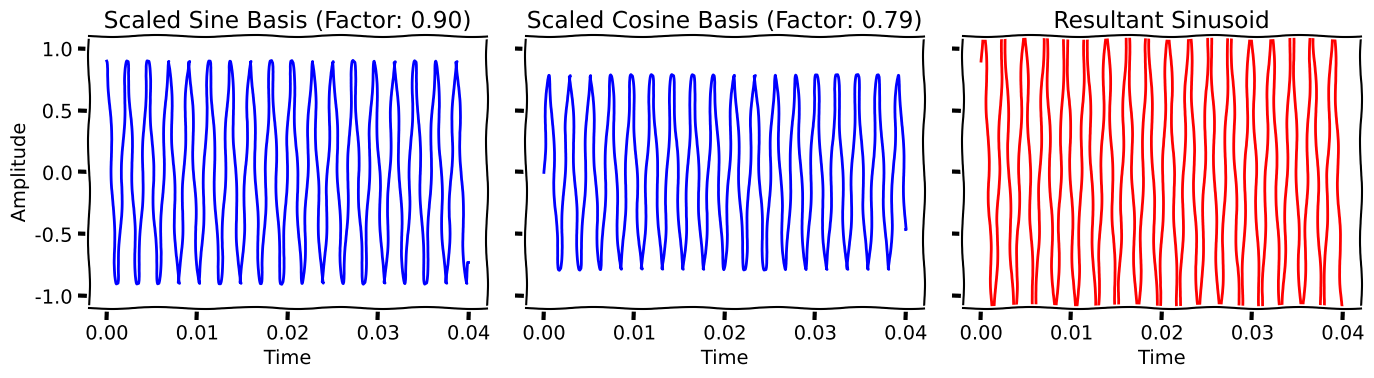

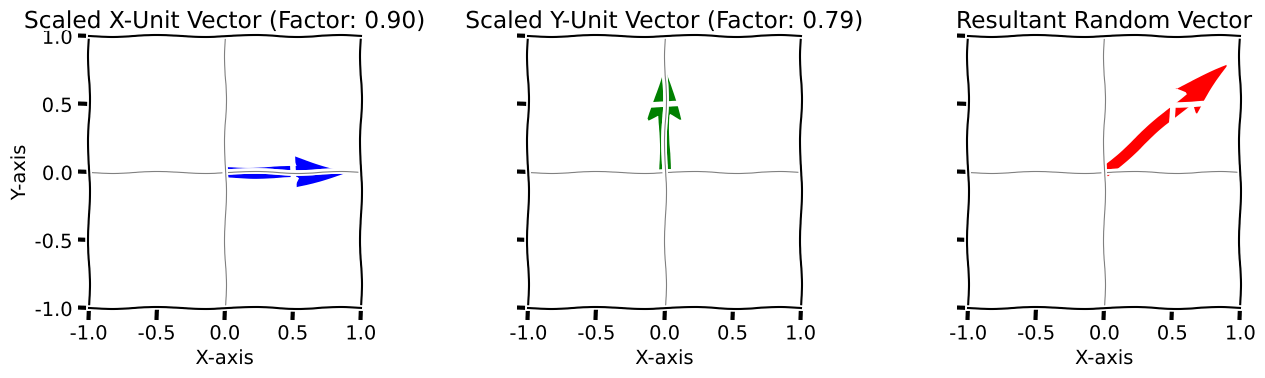

In [2]:
srate = 22050
def generate_sinusoid(amp = 1.0, freq = 440.0, phase=0.0, dur = 1.0, srate=srate):
    t = np.linspace(0,dur, int(srate* dur))
    data = amp * np.sin(2*np.pi*freq*t+phase)
    return (t,data)


def dot_amplitude(audio, basis):
    dur = audio.shape[0] / srate
    dot_product = np.dot(audio, basis)
    return 2 * (dot_product / len(audio))


(t,sin_basis) = generate_sinusoid(freq = 440, dur = 0.04,amp = 1.0, phase = np.pi/2)
(t,cos_basis) = generate_sinusoid(freq = 440, dur = 0.04,amp = 1.0, phase = 0)

import random
# Generate a random float between -1.0 and 1.0
rnd1 = random.uniform(0.5,1)
rnd2 = random.uniform(0.5,1)

mix = rnd1 * sin_basis + rnd2 * cos_basis
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

# Plot sin_basis
axes[0].plot(t[0:1000], rnd1 * sin_basis[0:1000], lw=2, color='blue')
axes[0].set_title(f'Scaled Sine Basis (Factor: {rnd1:.2f})')

axes[0].set_xlabel('Time')
axes[0].set_ylabel('Amplitude')
axes[0].set_ylim(-1.1, 1.1)

# Plot cos_basis
axes[1].plot(t[0:1000], rnd2 * cos_basis[0:1000], lw=2, color='blue')
axes[1].set_title(f'Scaled Cosine Basis (Factor: {rnd2:.2f})')
axes[1].set_xlabel('Time')
axes[1].set_ylim(-1.1, 1.1)

# Plot mix
axes[2].plot(t[0:1000], mix[0:1000], lw=2, color='red')
axes[2].set_title('Resultant Sinusoid')
axes[2].set_xlabel('Time')
axes[2].set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()

# Define the standard 2D unit vectors
i = np.array([1, 0])  # Unit vector along x-axis
j = np.array([0, 1])  # Unit vector along y-axis

# Calculate scaled vectors and their sum
scaled_i = rnd1 * i
scaled_j = rnd2 * j
resultant_vector = scaled_i + scaled_j

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

# Common plot settings
for ax in axes:
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)
    ax.axhline(0, color='grey', linewidth=0.8)
    ax.axvline(0, color='grey', linewidth=0.8)

# Plot scaled i
axes[0].quiver(0, 0, scaled_i[0], scaled_i[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.040)
axes[0].set_title(f'Scaled X-Unit Vector (Factor: {rnd1:.2f})')
axes[0].set_xlabel('X-axis')
axes[0].set_ylabel('Y-axis')

# Plot scaled j
axes[1].quiver(0, 0, scaled_j[0], scaled_j[1], angles='xy', scale_units='xy', scale=1, color='green', width=0.040)
axes[1].set_title(f'Scaled Y-Unit Vector (Factor: {rnd2:.2f})')
axes[1].set_xlabel('X-axis')

# Plot resultant vector
axes[2].quiver(0, 0, resultant_vector[0], resultant_vector[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.040)
axes[2].set_title('Resultant Random Vector')
axes[2].set_xlabel('X-axis')

plt.tight_layout()
plt.show()

Let's see if we can recover the two random numbers using cross-correlation with the cosine and sine probe/basis pair. As expected the two random numbers are recovered which is remarkable. Also let's look at what happens when we try to estimate the amplitude of sine_basis using the cos_basis. Because the two signals cancel each other their dot product is approximately zero. This is what is called orthogonality because when we are considering vectors this means the two vectors are perpendicular to each other.


In [3]:
rnd1 = dot_amplitude(mix, sin_basis)
rnd2 = dot_amplitude(mix, cos_basis)
print(f'Recovered random numbers: {rnd1:.2f}, {rnd2:.2f}')

est = dot_amplitude(sin_basis, cos_basis)
print(f'Amplitude Estimate: {est:.4f}')


Recovered random numbers: 0.91, 0.79
Amplitude Estimate: 0.0036


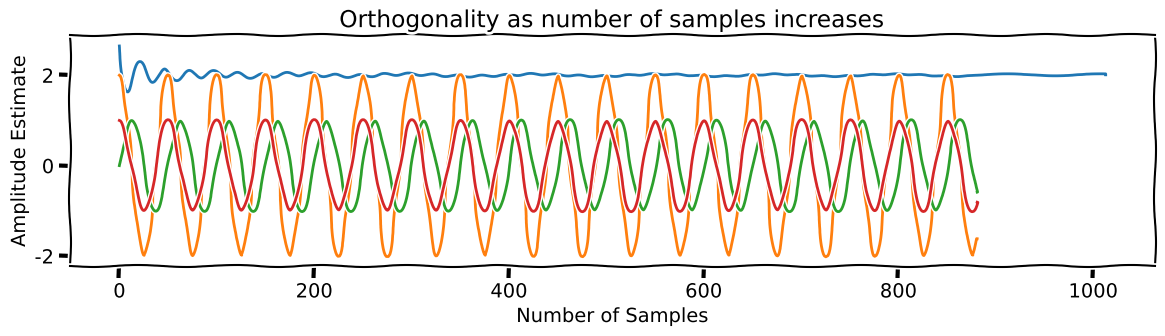

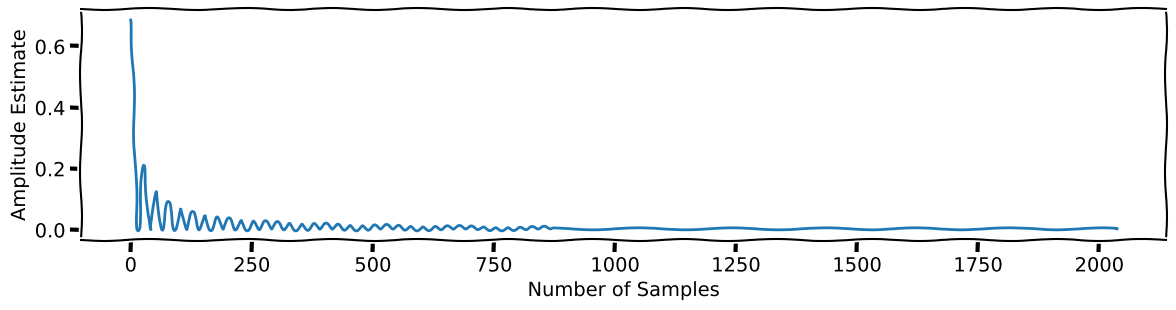

In [4]:
two_s = 2.0 * sin_basis

estimates = []
for k in np.arange(10, 1024):
  est = dot_amplitude(two_s[0:k], sin_basis[0:k])
  estimates.append(est)

plt.figure(figsize=(14,3))
plt.title('Progressive amplitude estimates as number of samples increases')
plt.xlabel('Number of Samples')
plt.ylabel('Amplitude Estimate')
plt.plot(estimates)
plt.plot(two_s)
plt.plot(cos_basis)
plt.plot(sin_basis)

plt.title('Orthogonality as number of samples increases')
estimates = []
for k in np.arange(10, 2048):
  est = dot_amplitude(cos_basis[0:k], sin_basis[0:k])
  estimates.append(est)

plt.figure(figsize=(14,3))
plt.xlabel('Number of Samples')
plt.ylabel('Amplitude Estimate')
plt.plot(estimates)
plt.show()



So let's recap. If we know what frequency we are interested in we can create a reliable and robust amplitude and phase estimator that utilizes a pair of sine and cosine **probe/basis** signals. Obviously if we only have a few samples and not a full cycle of our periodic signals that is going to reduce the accuracy of our amplitude (and phase) estimation. We need to have at least a few cycles of our target signal and our pair of probes and the estimation works best when the signal contain complete (integer number of) cycles. The two probes are orthogonal to each other meaning that their dot-product is zero.

So far for everything we have done we have used very basic operations between arrays of samples: calculating values of the sine and cosine function, additions, and multiplications. We will slowly start introducing some more advanced mathematical jargon, concepts, and associated notation.

**Further Reading - Digital Signal Processing** You might wander if we can do amplitude estimation using a pair of basis functions that are related by a phase change of 90 degrees or $\frac{\pi}{2}$ d(like the cosine and sine pair). The answer is yes (with some caveats that we won't get into) and the more general term is a guadrature pair (90 degrees is a quarter of a cycle). A related concept in signal processing is what is called the **Hilbert** transform in which different frequencies of a more complex signal are shifted by $\frac{\pi}{2}$ and can be used for various tasks such as amplitude envelope analysis and instanteneous frequency estimation.








## Upper, lower frequency limits and number of frequencies

We have a mechanism to reliably estimate in the presence of interference the amplitude and phase of a sinudoid if we know the frequency we are looking for.
We also know that this works best if we consider an integer number of cycles.
Let's assume that we are given an array of digital audio samples and we want to use our **probe/basis** pair estimators to analyze this array. If have no knowledge of what frequencies to look for what can we do ?

Let's first establish intuitively lower and upper boundaries for the frequencies to consider. If we consider sinusoidal signal then the **lowest** frequency we can fit in an array of **N** samples with a sampling rate **S** is what is sometimes called the **fundamental frequency** of the window $f_{min} = \frac{S}{N}$. The highest frequency that we can fit in an array of **N** samples is half the sampling rate: $f_{max} = S/2$. Intuitively we need at least two samples per cycle (one for the positive peak and one for the negative peak of a waveform).

Now that we have established a lower frequency limit and a higher frequency limit we need to decide how many frequencies we will consider for our analysis.
From a theoretical perspective as long as we have a (quadrature) pair of sines and cosines probes for each frequency we are interested in there is no restriction to how many frequencies we consider and how they are spaced other than the cost of computation.

As a hypothetical examples let's say we are interested in a complex sound generated by additive synthesis using $10$ sinusoidal components of known frequencies but unknown amplitudes and phases for each component. We can create $10$ **probe/basis** arrays of samples storing sines and cosines corresponding to each of these $10$ frequencies and then estimate their amplitude and phases. If everything works we should then be able to **reconstruct** the signal we are analyzing by combining sinusoids of the known frequencies with the estimated amplitudes and phases. If our estimates are accurate the it is possible that the **reconstructed** signal is identical to the original complex sound that is being analyzed. This is called **perfect reconstruction** and is an important property that will come back to.

The problem is that for analyzing an arbitrary array of $N$ audio samples we don't know what frequencies to consider. We have already seen that when the target frequency and the probe/basis pair frequency do not match exactly then the amplitude and phase estimation deteriorates the further apart the target frequency and the probe frequency are. We already have a lower and upper frequency bound so we can make the further decision to "space" our probes  linearly so that they are equally distant in frequency space to each other. The last remaining question is how many such frequency-specific probes should we use ? As we have $N$ audio samples how about we try $N$ amplitude and phase estimators linearly spaced by the lower and upper frequency limit ?

It turns out that if we do this what we have is what is called the **Discrete Fourier Transform** which is fundamental in understanding audio and music processing using computers.


**Further reading - Digital Signal Processing:**

Read about the **Nyquist** theorem and aliasing.





## Some DSP Notation

Let's now turn our attention to how we can notate these probe/basis pair frequencies between our lower and upper limit that are spaced linearly.
If we have $N$ time domain samples intuitively what we are aiming for is to have let's say a cosine basis function (array of $N$ samples) that completes exactly one full cycle in those $N$ samples, then another that completes two full cycles in those $N$ samples, and so forth. Note that as far as the samples of the cosine basis computed we don't need to know the sampling rate. If we have $N$ time domain samples they could be audio samples with 22050 or 44100 samples per second or they could be temperature readings from a senor that takes measurements every second, or it could be an economics indicator measured every day. Typically in programming languages the argument to the $\cos$ function is measured in radians and therefore a full cycle will correspond to $2\pi$. Therefore the first sample will be $\cos(0)$ and the last sample will be $\cos(2\pi)$ if we want a single full cycle and we have $N$ samples linearly spaced in between. Therefore our first probe will be:
$\cos(t * \frac{2 \pi}{N})$. Essentially the argument to the cosine probe/basis function samples the full cirle with $N$ angle samples (the same applies to the sine probe/basis function). If we want $2$ full cycles then we have $\cos(t * 2 *  \frac {2 \pi}{N})$, if we have 3 full cycles $\cos(t * 3 * \frac{2 \pi}{N}$ so the $k$th frequency will have samples $\cos(t * k * \frac{2 \pi}{N})$ where $0 \leq t \leq N-1$. It is important to understand that now are probes/basis functions are designed based on the number of samples that we are analyzing.

The expression thinking in circles is typically used as a bad thing but in this case literally it help us to think in circles because of the sampling of the angle. As we learn more about DSP mathematical notation thinking in circles will provide us with a lot of understanding and insight and eventually become second nature.


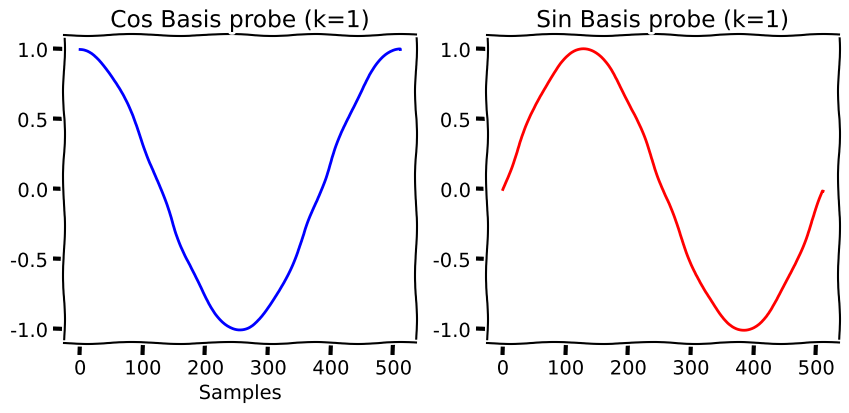

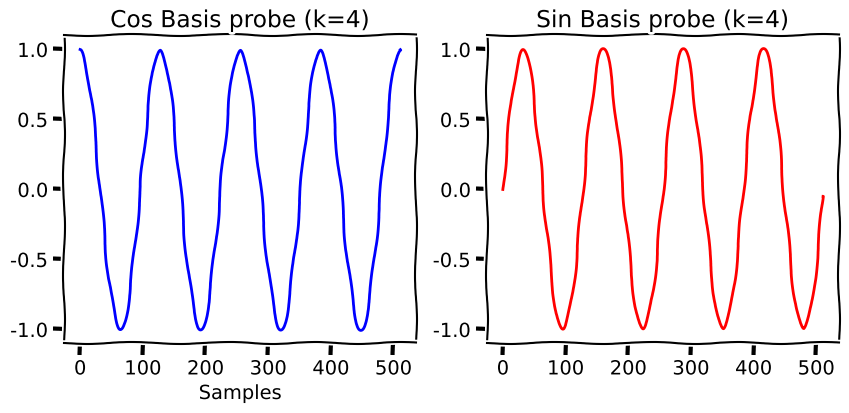

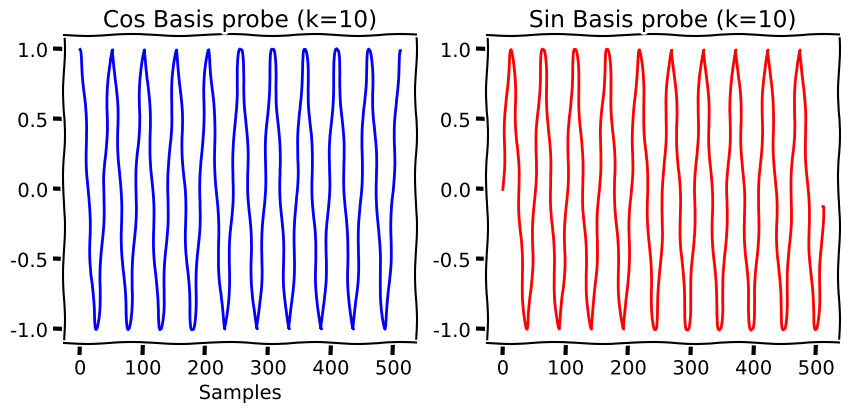

In [5]:
def plot_basis(t, cos_basis, sin_basis, k):
    # plot them
    plt.figure(figsize=(10,4))
    plt.subplot(121)
    plt.title("Cos Basis probe (k="+str(k)+")")
    plt.xlabel("Samples")

    plt.plot(t, cos_basis, lw=2, color='blue')
    plt.subplot(122)
    plt.title("Sin Basis probe (k="+str(k)+")")
    plt.plot(t, sin_basis, lw=2, color='red')

N = 512
t = np.arange(0,N)

# basis cos and sin probe/basis functions for k=1
k = 1
cos_basis = np.cos(k*t*2*np.pi/N)
sin_basis = np.sin(k*t*2*np.pi/N)
plot_basis(t, cos_basis, sin_basis,k)

# basis cos and sin probe/basis functions for k=4
k = 4
cos_basis = np.cos(k*t*2*np.pi/N)
sin_basis = np.sin(k*t*2*np.pi/N)
plot_basis(t, cos_basis, sin_basis,k)


# basis cos and sin probe/basis functions for k=10
k = 10
cos_basis = np.cos(k*t*2*np.pi/N)
sin_basis = np.sin(k*t*2*np.pi/N)
plot_basis(t, cos_basis, sin_basis,k)


## Frequency 0 and DC offset

We are almost ready to finally get into how the Discrete Fourier Transform works but before that we need to mention a small detail.

When $k=0$ we have the cosine and sine of $0$ which is $1$ and $0$ respectively basically a constant signal. If we have a constant signal in the input we can find it's value by taking the dot-product with a constant signal of unit amplitude. Audio signals are typically centered at $0$ but in other applications such as electrical signal modeling (DC offset) there can be a constant offset for which having this $0$ frequency basis is useful.

## The Discrete Probe Transform

Before going into the official version of the DFT let's examine a variation that is based on what we have learned so far. First let's hear some of the basis/probe functions by considering a larger window of samples and a realistic sampling rate. They are basically sine tones and as we covered in Part 1 we can create melodies by concatenating them in time and more complex sounds by adding them together.






In [6]:
N = 4098
srate = 22050
t = np.arange(0,N)

k = 3
another_basis = np.cos(k*t*2*np.pi/N)

# basis cos and sin probe/basis functions for k=40, 100
k = 40
cos_basis = np.cos(k*t*2*np.pi/N)

k = 100
sin_basis = np.sin(k*t*2*np.pi/N)
audio = np.hstack(( 0.5 * cos_basis, sin_basis, sin_basis,  cos_basis))

# Sequential playback
ipd.Audio(audio, rate=srate)



In [7]:
audio = 0.5 * cos_basis + sin_basis
# simultaneous playback
ipd.Audio(audio, rate=srate)

Notice we can perfectly recover the amplitudes in this case using the dot-product amplitude estimation. That is the **analysis** direction of the transform.

In [8]:
print(f"Cos basis amplitude: {dot_amplitude(audio, cos_basis):.3f}")
print(f"Sin basis amplitude: {dot_amplitude(audio, sin_basis):.3f}")
print(f"Another basis amplitude: {dot_amplitude(audio, another_basis):.3f}")


Cos basis amplitude: 0.500
Sin basis amplitude: 1.000
Another basis amplitude: 0.000


Suppose we have these amplitudes and we want to regenerate the mixture audio. We could use the generate_sinusoid function to compute each sinusoid for the corresponding "frequencies" (k=3, k=40, k=100) but we can do something easier.
We have the already computed cosine and sine basis arrays so we can simply scale them appropriately and add them. That is the **re-synthesis** direction of the tranform and you can see that we get perfect reconstruction.

In [9]:
audio = 0.5 * cos_basis + 1.0 * sin_basis + 0 * another_basis
ipd.Audio(audio, rate=srate)

We are now ready to put together the **analyis** part and the **re-synthesis** part as a functions. This is called a transform as it changes the representation of our signal from the **time** domain to what is called the **frequency** domain for obvious reasons. For each of the $\frac{N}{2}$ linearly spaced analysis frequencies we estimate the amplitude using the pair of cosine and sine probes/basis functions.



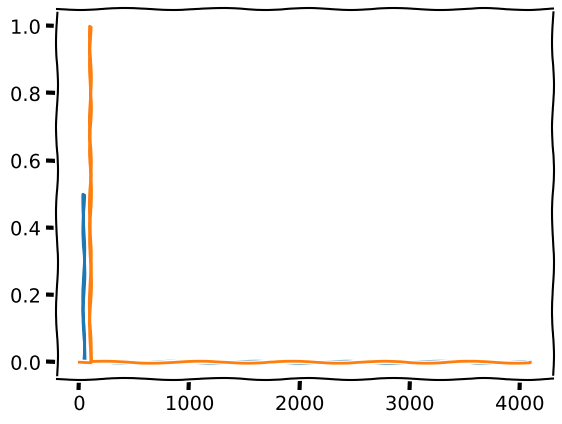

In [10]:
# FORWARD PROBE TRANFORM

cos_amplitudes = np.zeros(N)
sin_amplitudes = np.zeros(N)
cos_basis = np.zeros(N)
sin_basis = np.zeros(N)

for k in range(0, N//2):
  t = np.arange(0,N)
  cos_basis = np.cos(k*t*2*np.pi/N)
  sin_basis = np.sin(k*t*2*np.pi/N)
  cos_amplitudes[k] = dot_amplitude(audio, cos_basis)
  sin_amplitudes[k] = dot_amplitude(audio, sin_basis)

plt.plot(cos_amplitudes)
plt.plot(sin_amplitudes)
plt.show()


We can now take these arrays of cosine basis amplitude estimate and sine basis amplitude estimates and recontruct (perfectly) our original input by simply multiplying the corresponding probe/basis function and adding them together. This is called the **Inverse** transform and corresponds to a **re-synthesis** of our original input from the frequency-domain representation.



In [11]:
# INVERSE PROBE TRANFORM

output = np.zeros(N)
for k in range(0, N//2):
  t = np.arange(0,N)
  cos_basis = np.cos(k*t*2*np.pi/N)
  sin_basis = np.sin(k*t*2*np.pi/N)
  output += cos_amplitudes[k] * cos_basis + sin_amplitudes[k] * sin_basis

ipd.Audio(output, rate=srate)

We can now write the complete discrete probe transform in both directions (analysis and re-synthesis) that takes us from the time-domain to a frequency-domain and back. We will call the frequency domain representation i.e the amplitude estimates for how the cosine and sine basis/probe signals have to be combined to re-construct the original input the **spectrum**.

Note that in the code below the spectrum is a reprsented as a list of tupples where each tupple corresponds to a frequency **k**. We saw that we got **perfect reconstruction** in the previous examples but are input consisted of a mix of sinudois that corresponded direcltly to the linear frequency grid of the analysis and had integer number of cycles present in the input mixture signal. We have seen that the amplitude estimates if the input and analysis frequencies do not match are not as accurate and also not having an integer number of cycles in the input can be detetrimental to the accuracy of the amplitude estimates. Remarkably, and there are some deep mathematical reasons behind this which we will not cover, we are able to get perfect reconstruction using our analysis/re-synthesis approach for any input signal.

Let's check an example using a trumpet sound.


In [12]:

def analysis_probe_transform(audio, N):
  spectrum = []

  for k in range(0, N//2):
    t = np.arange(0,N)
    cos_basis = np.cos(k*t*2*np.pi/N)
    sin_basis = np.sin(k*t*2*np.pi/N)
    cos_amplitudes[k] = dot_amplitude(audio, cos_basis)
    sin_amplitudes[k] = dot_amplitude(audio, sin_basis)
    spectrum.append((cos_amplitudes[k], sin_amplitudes[k]))
  spectrum = np.array(spectrum)
  return spectrum


def resynthesis_probe_transform(spectrum, N):
  output = np.zeros(N)
  for k in range(0, N//2):
    t = np.arange(0,N)
    cos_basis = np.cos(k*t*2*np.pi/N)
    sin_basis = np.sin(k*t*2*np.pi/N)
    cos_amp = spectrum[k,0]
    sin_amp = spectrum[k,1]
    output += cos_amp * cos_basis + sin_amp * sin_basis
  return output


filename = librosa.ex('trumpet')
trumpet, sr = librosa.load(filename)
trumpet = trumpet[0:4096]
print(trumpet.shape)
ipd.Audio(trumpet, rate=srate)

(4096,)


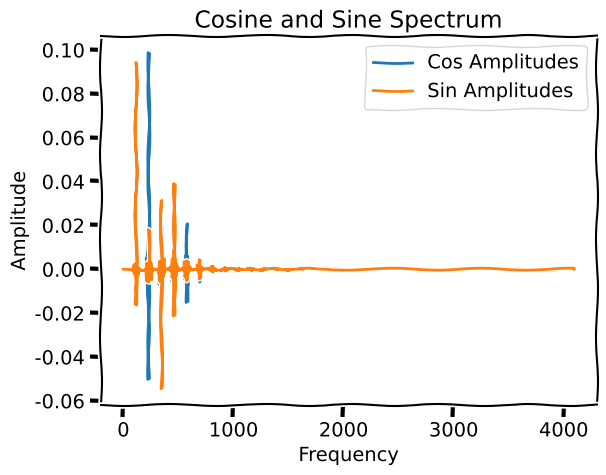

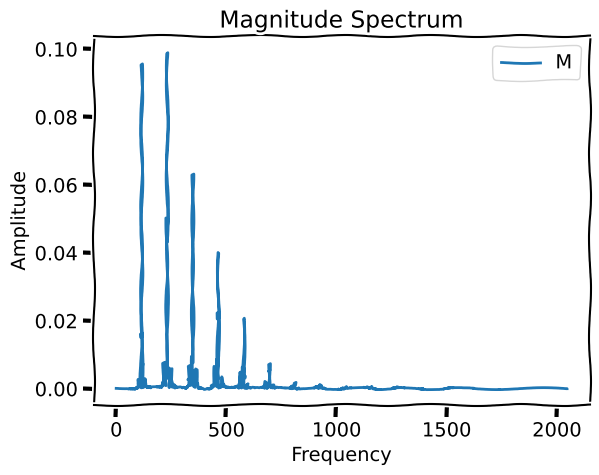

In [20]:
spectrum = analysis_probe_transform(trumpet, 4096)
magnitude_spectrum = [np.sqrt(c**2 + s**2) for c, s in spectrum]

plt.plot(cos_amplitudes)
plt.plot(sin_amplitudes)
plt.title('Cosine and Sine Spectrum')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.legend(('Cos Amplitudes', 'Sin Amplitudes'))
plt.show()

plt.plot(magnitude_spectrum)
plt.title('Magnitude Spectrum')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.legend('Magnitude')
plt.show()

resynthesized_audio = resynthesis_probe_transform(spectrum, 4096)
ipd.Audio(resynthesized_audio, rate=srate)


## Sidenote about re-synthesis


In [24]:
t = np.arange(0,N)
for k in range(0, N//2):
  cos_basis = np.cos(k*t*2*np.pi/N)
  sin_basis = np.sin(k*t*2*np.pi/N)

amp = 0.75
phase = np.pi / 5

cos_amp = amp * np.cos(k*t*2*np.pi/N + phase)
sin_amp = amp * np.sin(k*t*2*np.pi/N + phase)

# explicitly calcluate the output
output1 = amp * np.sin(50 * t * 2 * np.pi / N + phase)
ipd.Audio(output, rate=srate)


In [25]:
# calculate the output using the basis functions

output2 = cos_amp * cos_basis + sin_amp * sin_basis
ipd.Audio(output, rate=srate)

These two ways are equivalent in terms of output however the second way is much faster as we don't have to recompute the samples of the sinusoid we just have to multiply the basis arrays and sum them together. The exact details will depend on your hardware but you can see on my laptop there is about a 10 percent slowdown when recomputing the samples compared to doing resynthesis by using multiplication and addition of the probe/basis arrays.

In [40]:
%%timeit -r 3 -n 10000
output1 = amp * np.sin(50 * t * 2 * np.pi / N + phase)

116 µs ± 22 µs per loop (mean ± std. dev. of 3 runs, 10000 loops each)


In [41]:
%%timeit -r 3 -n 10000
output2 = cos_amp * cos_basis + sin_amp * sin_basis

11 µs ± 114 ns per loop (mean ± std. dev. of 3 runs, 10000 loops each)



# The Discrete Fourier Transform  


We are finally ready to explore the Discrete Fourier Transform which is a fundamental algorithm in Digital Signal Processing.

















First let's look at the typical mathematical notation:

\begin{equation}
X_k = <x, e^{jtk2\pi /N}> = \sum_{t=0}^{N-1} x_t e^{-j t k 2 \pi/N}  
\end{equation}

We start with a finite, length-N segment of a digital signal $x_0, x_1, \dots, x_{N-1}$. We define the inner product as:
\begin{equation}
<x,y> = \sum_{t=0}^{N-1} x_t y_t^*
\end{equation}
and the corresponding basis is N frequency cosine and sine probe pairs
 equally spaced in the desired rage from zero to the sampling frequency:
\begin{equation}
{e^{jtk2\pi/N}} = {cos(tk2\pi/N) + j sin(tk2\pi/N})\;\;\; \text{for} \;\; 0 \leq k \leq N-1
\end{equation}

This is a typical description you can find in a Digital Signal Processing textbook or Wikipedia and contains a bunch of math notation we have not covered but as we will see essentially we are using N "basis/probes" to estimate the corresponding amplitudes and phases of the sinusoids present in a sound mixture based on all the ideas we have covered so far in Part 1, 2, and 3.



In [ ]:
N = 512
t = np.arange(0,N)

# basis cos and sin probe/basis functions for k=1
k = 1
cos_basis = np.cos(k*t*2*np.pi/N)
sin_basis = np.sin(k*t*2*np.pi/N)
plot_basis(t, cos_basis, sin_basis, k)

# basis cos and sin probe/basis functions for k=4
k = 4
cos_basis = np.cos(k*t*2*np.pi/N)
sin_basis = np.sin(k*t*2*np.pi/N)
plot_basis(t, cos_basis, sin_basis, k)


# basis function real and imaginary parts for k=10
k = 10
cos_basis = np.cos(k*t*2*np.pi/N)
sin_basis = np.sin(k*t*2*np.pi/N)

plot_basis(t, cos_basis, sin_basis, k)


\begin{equation}
X_k = <x, e^{jtk2\pi /N}> = \sum_{t=0}^{N-1} x_t e^{-j t k 2 \pi/N}  = \sum_{t=0}^{N-1} x_t cos(tk2\pi/N) + \sum_{t=0}^{N-1} x_t  j sin(tk2\pi/N)
\end{equation}

Looking at the equation above you can see that for a specific k the complex spectrum value X_k can be computed by taking two inner products for the input signal $x_t$ with the real and imaginary parts of the corresponding basis function.

Let's consider as input a cosine signal of the same frequency as a particular pair of basis functions let's say with $k=4$ and look at the signal resulting from the point-wise multiplication of the input with the real part and the imagine part. As you can see the point-wise multiplication with the real part results in a signal that is centered above zero and therefore the inner product is positive (the value is shown with the straight black line in the plot). The point-wise multiplication with the imaginary part results in a signal that is centered at zero and therefore the inner product is zero (the value is shown with the straight black line in the plot). Recall from before when we examined using the inner product with a sinusoid of known frequency to estimate amplitude that the estimated amplitude is simply twice the inner product.

In [ ]:
def plot_product(t,x1,x2):
    prod = np.multiply(x1,x2)
    inner_prod = np.sum(prod) / len(prod)
    plt.figure(figsize=(20,5))
    plt.plot(t, x1,'.', lw=1, color='blue')
    plt.plot(t, x2,'.', lw=1, color='cyan')
    plt.plot(t, np.multiply(x1,x2), lw=4, color='red')
    ip_line = np.empty(len(prod))
    ip_line.fill(inner_prod)
    plt.plot(t, ip_line, lw=4, color='black')
    plt.plot(t, ip_line*2, lw=2, color='black')
    plt.legend(('x', 'x_basis', 'point-wise product', 'inner product', 'amplitude estimate'), loc='upper right')


k=4
a = 0.6
x = a * np.cos(k*t*2*np.pi/N)
x_re = np.cos(k*t*2*np.pi/N)
x_im = np.sin(k*t*2*np.pi/N)
plot_product(t,x,x_re)
plot_product(t,x,x_im)

When the input is a sine wave the inner product with the real part of the basis is zero and the inner product with the imaginary part of the basis is positive.

In [ ]:

x = a * np.sin(k*t*2*np.pi/N)
plot_product(t,x,x_re)
plot_product(t,x,x_im)


Now let's consider the case of using as input a sinusoidal signal of different frequency let's say corresponding to k=10. As you can observe in this case the inner products with both the real and imaginary part of the basis functions are zero.

In [ ]:
k=10
x = a * np.sin(k*t*2*np.pi/N)
plot_product(t,x,x_re)
plot_product(t,x,x_im)

Now consider an input that is a mixure of two sinsoids. Notice that we are still able to correctly estimate the amplitude of the mixture component that corresponds to the basis function we are using.

In [ ]:
k=4
a1 = 0.8
x1 = a1 * np.sin(k*t*2*np.pi/N)
a2 = 0.4
k = 10
x2 = a2 * np.sin(k*t*2*np.pi/N)
x = x1+x2
plot_product(t,x,x_re)
plot_product(t,x,x_im)

Finally lets look at computing the Discrete Fourier Transform directly from the equation and viewing the magnitude spectrum for the mixture signal we examined above. The code is written so that the connection to measuring amplitude and phases using inner products with the real and imaginary parts of each basis element is emphasized and the code does not utilize the complex number type. Notice the normalization by 2/N so that the mangitude spectrum shows the estimated amplitudes of the input signal.

In [ ]:
def pedagogical_dft(x, N):
    X_re = np.zeros(N)       # array holding the real parts of the spectrum
    X_im = np.zeros(N)       # array holding the imaginary values of the spectrum
    for k in np.arange(0,N):
        for t in np.arange(0,N):
            X_re[k] += x[t] * np.cos(t * k * 2 * np.pi / N)   # inner product with real basis k
            X_im[k] += x[t] * np.sin(t * k * 2 * np.pi / N)   # inner product with imaginary basis k
    return (X_re, X_im)

def plot_mag_spectrum(Xmag):
    plt.figure(figsize=(20,5))
    n = np.arange(0,len(Xmag))
    plt.plot(n,Xmag)

N = 512
n = np.arange(0,N)

# Single sinusoid
k=100
x1 = 1.5 * np.sin(k*n*2*np.pi/N)

(X_re, X_im) = pedagogical_dft(x1, N)
Xmag = 2 * np.sqrt(X_re * X_re + X_im * X_im) /N
plot_mag_spectrum(Xmag)

In [ ]:
# Mixture sinusoid input
x2 = np.sin(50*n*2*np.pi/N) + 0.5 * np.sin(100 * n * 2 * np.pi/N) + 0.3 * np.sin(300 * n * 2 * np.pi/N)

(X_re, X_im) = pedagogical_dft(x2, N)
Xmag = 2 * np.sqrt(X_re * X_re + X_im * X_im) / N
plot_mag_spectrum(Xmag)


In [ ]:
X = np.fft.fft(x1)
Xmag = 2 * np.abs(X) / N
plot_mag_spectrum(Xmag)

X = np.fft.fft(x2)
Xmag = 2 * np.abs(X) / N
plot_mag_spectrum(Xmag)

In [ ]:
%%time
import numpy as np
import timeit

def pedagogical_dft(x, N):
    X_re = np.zeros(N)       # array holding the real parts of the spectrum
    X_im = np.zeros(N)       # array holding the imaginary values of the spectrum
    for k in np.arange(0,N):

        for t in np.arange(0,N):
            X_re[k] += x[t] * np.cos(t * k * 2 * np.pi / N)   # inner product with real basis k
            X_im[k] += x[t] * np.sin(t * k * 2 * np.pi / N)   # inner product with imaginary basis k
    return (X_re, X_im)

def test():
    x = np.zeros(512)
    for i in range(10):
      pedagogical_dft(x,512)

test()

In [ ]:
%%time
import numpy as np
import timeit

def test():
    for i in range(10):
      x = np.zeros(512)
      np.fft.fft(x)

test()

In [ ]:
filename = librosa.ex('fishin')
fishin, sr = librosa.load(filename)
ipd.Audio(fishin, rate=sr)

In [ ]:
import scipy.fft as fft
import random

y = trumpet[0:100000]
#y = fishin[0:10000]
complex_spectrum = fft.rfft(y)

magnitude_spectrum = np.abs(complex_spectrum)
print(len(complex_spectrum))
bin = 10

#mags = magnitude_spectrum[bin:bin+10000]
#magnitude_spectrum = np.zeros(len(magnitude_spectrum))
#magnitude_spectrum[bin:bin+10000] = mags

#magnitude_spectrum = np.roll(np.abs(complex_spectrum), -1000)
magnitude_spectrum = np.ones(len(magnitude_spectrum))
# magnitude_spectrum = np.abs(complex_spectrum)
phase_spectrum = np.angle(complex_spectrum)
# phase_spectrum[0:int(len(magnitude_spectrum))] = np.random.uniform(0, 2*np.pi, int(len(magnitude_spectrum)))

reconstructed_complex_spectrum  = magnitude_spectrum*(np.cos(phase_spectrum)+1j*np.sin(phase_spectrum))
reconstructed = fft.irfft(reconstructed_complex_spectrum)
fig = plt.figure(figsize=(6,2))
plt.xlabel("Time in samples")
plt.ylabel("Amplitude")
plt.plot(reconstructed[0:1000], lw=2, color='blue')
plt.plot(y[0:1000], lw=2, color='blue')

plt.show()
ipd.Audio( reconstructed,rate=sr, normalize=True)



In [ ]:
a = np.concatenate([reconstructed, reconstructed, reconstructed], axis=0)
print(a.shape)

In [ ]:
ipd.Audio(a,rate=sr, normalize=True)

In [ ]:
import scipy.signal as signal
audio_signal = trumpet
hopSize = 256
winSize = 1024
offsets = np.arange(0, len(audio_signal), hopSize)

output = np.zeros(len(audio_signal))
spectrogram = []
times = []
for (m,o) in enumerate(offsets):
    frame = audio_signal[o:o+winSize]
    if len(frame) < winSize:
            break  # Ignore incomplete segment
    window = signal.windows.hann(len(frame))
    mag_spectrum = np.abs(np.fft.fft(frame)[:winSize // 2])
    spectrogram.append(mag_spectrum)
    frame = window * frame
    output[o:o+winSize] += frame
    times.append((o + winSize) / sr)

spectrogram = np.array(spectrogram).T
frequencies = np.fft.fftfreq(winSize, d=1/sr)[:winSize // 2]

ipd.Audio(output, rate=sr)

In [ ]:
a = [1, 2, 4,5, 6]
print(a[:3])
winSize = 1024
print(winSize /2)
print(winSize // 2)

In [ ]:
# Plot the spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(times, frequencies, 10 * np.log10(spectrogram + 1e-10), shading='gouraud', cmap='viridis')
#plt.pcolormesh(times, frequencies, spectrogram, shading='gouraud', cmap='viridis')

plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.title('Spectrogram')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

In [ ]:
# Plot the spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(times, frequencies, spectrogram, shading='gouraud', cmap='viridis')
#plt.pcolormesh(times, frequencies, spectrogram, shading='gouraud', cmap='viridis')

plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.title('Spectrogram')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

In [ ]:
import scipy.signal as signal
audio_signal = trumpet
hopSize = 1 * 512
winSize = 1 * 4096
offsets = np.arange(0, len(audio_signal), hopSize)

output = np.zeros(len(audio_signal))
spectrogram = []
times = []
for (m,o) in enumerate(offsets):
    frame = audio_signal[o:o+winSize]
    if len(frame) < winSize:
            break  # Ignore incomplete segment
    window = signal.windows.hann(len(frame))
    windows = np.ones(len(frame))
    #mag_spectrum = np.abs(np.fft.fft(frame)[:winSize // 2])
    #spectrogram.append(mag_spectrum
    complex_spectrum = np.fft.fft(window*frame)
    mag_spectrum = np.abs(complex_spectrum)
    sorted_mag_spectrum = np.sort(mag_spectrum)
    threshold = sorted_mag_spectrum[-4]
    mag_spectrum[mag_spectrum < threshold] = 0
    #spectrogram.append(mag_spectrum)
    #mag_spectrum = np.ones(len(frame))
    phase_spectrum = np.angle(complex_spectrum)
    phase_spectrum[0:int(len(mag_spectrum))] = np.random.uniform(0, 2*np.pi, int(len(mag_spectrum)))
    #phase_spectrum = np.zeros(len(mag_spectrum))

    reconstructed_complex_spectrum  = mag_spectrum*(np.cos(phase_spectrum)+1j*np.sin(phase_spectrum))
    reconstructed_frame = np.real(fft.ifft(reconstructed_complex_spectrum))

    reconstructed = window * reconstructed_frame
    output[o:o+winSize] += reconstructed_frame
    times.append((o + winSize) / sr)

spectrogram = np.array(spectrogram).T
frequencies = np.fft.fftfreq(winSize, d=1/sr)[:winSize // 2]
ipd.Audio(output, rate=sr)

In [ ]:
import soundfile as sf
def plot_mag_spectrum(Xmag):
    plt.figure(figsize=(20,5))
    n = np.arange(0,len(Xmag))
    plt.plot(n,Xmag)

# load a C4 sine wave
x,srate = sf.read('sineC4.wav')
print(np.max(x))
ipd.Audio(x,rate=srate)

In [ ]:
N = len(x)
X = np.fft.fft(x)
Xmag = 2 * np.abs(X) / N
plot_mag_spectrum(Xmag)

In [ ]:
# load a C4 sine wave - notice that there are multiple peaks
# corresponding to the harmonics
x,srate = sf.read('cl_C4.wav')
print(np.max(x))
ipd.Audio(x,rate=srate)
ipd.Audio(x,rate=srate)

In [ ]:
N = len(x)
X = np.fft.fft(x)
Xmag = 2 * np.abs(X) / N
plot_mag_spectrum(Xmag)

In [ ]:
# let's zoom to the first 5000 values to see the harmonics better
plot_mag_spectrum(Xmag[1:5000])

In [ ]:
# load a 3 second excerpt from a jazz recording
x, srate = sf.read('freddie3sec.wav')
ipd.Audio(x,rate=srate)

In [ ]:
N = len(x)
X = np.fft.fft(x)
Xmag = 2 * np.abs(X) / N
plot_mag_spectrum(Xmag)
plot_mag_spectrum(Xmag[1:5000])

In [ ]:
def plot_mag_spectrum(Xmag, N):
    plt.figure(figsize=(20,5))
    n = np.arange(0,len(Xmag))
    plt.xlabel('Frequency as DFT bin')
    plt.plot(n,Xmag)

    plt.figure(figsize=(20,5))
    n = np.linspace(0.0, len(Xmag) *1.0 /N, num=len(Xmag))
    plt.xlabel('Frequency in fractions of sampling rate')
    plt.plot(n,Xmag)

    plt.figure(figsize=(20,5))
    n = np.linspace(0.0, (len(Xmag) *1.0 / N)*44100, num=len(Xmag))
    plt.xlabel('Frequency in Hz ')

    plt.plot(n,Xmag)

# load a C4 sine wave
x, srate = sf.read('freddie3sec.wav')
N = len(x)
X = np.fft.fft(x)
Xmag = 2 * np.abs(X) / N
plot_mag_spectrum(Xmag[1:5000], len(Xmag) )

In [ ]:
# load a C4 sine wave
x, srate = sf.read('sineC4.wav')
N = len(x)
X = np.fft.fft(x)
Xmag = 2 * np.abs(X) / N
plot_mag_spectrum(Xmag[1:1000], N)
Xmag = Xmag[1:1000]

In [ ]:
fractions   = np.linspace(0.0, len(Xmag) *1.0 /N, num=len(Xmag))
frequencies = np.linspace(0.0, (len(Xmag) *1.0 / N)*44100, num=len(Xmag))

# find the index (dft bin) of the peak
peak_bin = np.argmax(Xmag)
print('Index in bins: ', peak_bin)
print('Index in fractions of sampling rate', fractions[peak_bin])
print('Index in Hz: ', frequencies[peak_bin])
peak_freq = frequencies[peak_bin]
peak_midi = int(69 + 12*np.log2(peak_freq/440.))
print(peak_midi)